# 3. Classificação

Prever se a unidade fica **abaixo de 90%** no resultado geral. Comparamos XGBoost, LightGBM e CatBoost, cada um com grid search, e um stacking dos três com regressão logística como metamodelo. O melhor pela validação cruzada é o modelo final.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style='whitegrid')
SEMENTE = 20262

# a base com as features do caderno 2 e as categóricas já codificadas lá
df = pd.read_csv('../saidas/unidades_features.csv')
df['abaixo_90'] = (df['geral'] < 0.9).astype(int)
df.shape

(190, 29)

## Features

As notas dos quatro indicadores e as seis features criadas no caderno 2 (taxa de atendimento do indicador 1, indicador 3 x indicador 4, indicador 3 abaixo da meta, indicadores na meta, desvio entre os indicadores e média dos blocos do indicador 4). As categóricas chegam codificadas: família e distrito em one-hot, tipo em label encoding e o nível do tipo como ordinal.

In [2]:
# notas dos quatro indicadores, as seis features criadas, familia e distrito em one-hot,
# tipo em label encoding e o nível do tipo como ordinal. nada disso usa o resultado geral
X = df.drop(columns=['tipo', 'geral', 'abaixo_90'], errors='ignore')
y = df['abaixo_90']
X.shape

(190, 26)

## Balanceamento das classes

In [3]:
print(y.value_counts())
peso_positivo = (y == 0).sum() / (y == 1).sum()
print('razão negativos/positivos:', round(peso_positivo, 2))

abaixo_90
0    101
1     89
Name: count, dtype: int64
razão negativos/positivos: 1.13


As classes estão quase equilibradas, mas usamos mesmo assim separação estratificada e peso de classe em cada modelo (`scale_pos_weight` no XGBoost, `class_weight='balanced'` no LightGBM e `auto_class_weights='Balanced'` no CatBoost). A métrica do grid search é o F1, que não é enganada por desbalanceamento.

## Treino e teste

In [4]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEMENTE)
print(X_treino.shape, X_teste.shape)

(142, 26) (48, 26)


## Grid search

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)

modelos = {
    'XGBoost': (
        XGBClassifier(random_state=SEMENTE, eval_metric='logloss', scale_pos_weight=peso_positivo),
        {'n_estimators': [100, 300], 'max_depth': [2, 3, 5], 'learning_rate': [0.05, 0.1]},
    ),
    'LightGBM': (
        LGBMClassifier(random_state=SEMENTE, class_weight='balanced', verbose=-1),
        {'n_estimators': [100, 300], 'num_leaves': [7, 15], 'learning_rate': [0.05, 0.1]},
    ),
    'CatBoost': (
        CatBoostClassifier(random_state=SEMENTE, auto_class_weights='Balanced', verbose=0, allow_writing_files=False),
        {'iterations': [200, 500], 'depth': [3, 5], 'learning_rate': [0.05, 0.1]},
    ),
}

melhores = {}
f1_cv = {}
for nome, (modelo, grade) in modelos.items():
    busca = GridSearchCV(modelo, grade, cv=cv, scoring='f1', n_jobs=1)
    busca.fit(X_treino, y_treino)
    melhores[nome] = busca.best_estimator_
    f1_cv[nome] = busca.best_score_
    print(f'{nome}: {busca.best_params_} | F1 na validação cruzada = {busca.best_score_:.3f}')

XGBoost: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100} | F1 na validação cruzada = 0.985


LightGBM: {'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 7} | F1 na validação cruzada = 0.992


CatBoost: {'depth': 3, 'iterations': 200, 'learning_rate': 0.05} | F1 na validação cruzada = 1.000


## Stacking

In [6]:
stacking = StackingClassifier(
    estimators=[(nome, modelo) for nome, modelo in melhores.items()],
    final_estimator=LogisticRegression(),
    cv=cv,
)
f1_cv['Stacking'] = cross_val_score(stacking, X_treino, y_treino, cv=cv, scoring='f1').mean()
stacking.fit(X_treino, y_treino)
melhores['Stacking'] = stacking

pd.Series(f1_cv, name='F1 na validação cruzada').round(3)

XGBoost     0.985
LightGBM    0.992
CatBoost    1.000
Stacking    1.000
Name: F1 na validação cruzada, dtype: float64

## Escolha do modelo

O modelo final é o de maior F1 na validação cruzada, calculado só no treino. Em caso de empate, fica o que vem primeiro na lista, ou seja, um modelo único antes do stacking.

In [7]:
escolhido = max(f1_cv, key=f1_cv.get)
modelo_final = melhores[escolhido]
print('modelo escolhido:', escolhido)

modelo escolhido: CatBoost


## Resultados no teste

In [8]:
linhas = []
for nome, modelo in melhores.items():
    previsto = modelo.predict(X_teste)
    probabilidade = modelo.predict_proba(X_teste)[:, 1]
    linhas.append({
        'modelo': nome,
        'acurácia': accuracy_score(y_teste, previsto),
        'precisão': precision_score(y_teste, previsto),
        'recall': recall_score(y_teste, previsto),
        'f1': f1_score(y_teste, previsto),
        'auc': roc_auc_score(y_teste, probabilidade),
    })

resultados = pd.DataFrame(linhas).set_index('modelo').round(3)
resultados

,acurácia,precisão,recall,f1,auc
modelo,,,,,
XGBoost,1.0,1.0,1.0,1.0,1.0
LightGBM,1.0,1.0,1.0,1.0,1.0
CatBoost,1.0,1.0,1.0,1.0,1.0
Stacking,1.0,1.0,1.0,1.0,1.0


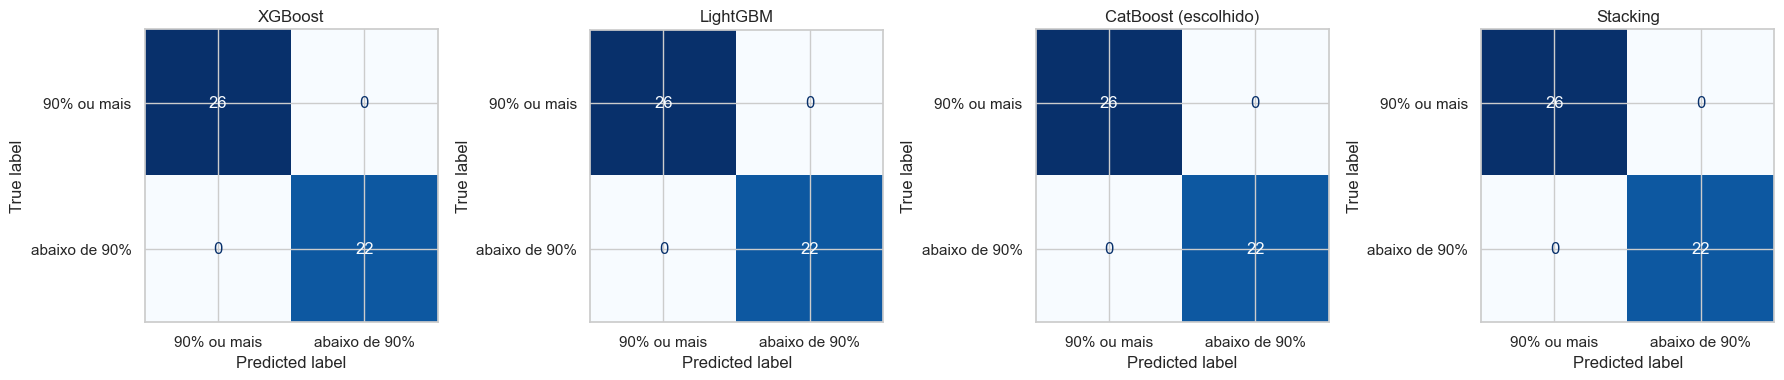

In [9]:
fig, eixos = plt.subplots(1, 4, figsize=(18, 4))
for eixo, (nome, modelo) in zip(eixos, melhores.items()):
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_teste, y_teste, display_labels=['90% ou mais', 'abaixo de 90%'], cmap='Blues', colorbar=False, ax=eixo
    )
    eixo.set_title(nome + (' (escolhido)' if nome == escolhido else ''))
plt.tight_layout()
plt.show()

In [10]:
previsto_final = modelo_final.predict(X_teste)
print(classification_report(y_teste, previsto_final, target_names=['90% ou mais', 'abaixo de 90%']))

               precision    recall  f1-score   support

  90% ou mais       1.00      1.00      1.00        26
abaixo de 90%       1.00      1.00      1.00        22

     accuracy                           1.00        48
    macro avg       1.00      1.00      1.00        48
 weighted avg       1.00      1.00      1.00        48



## Importância das features

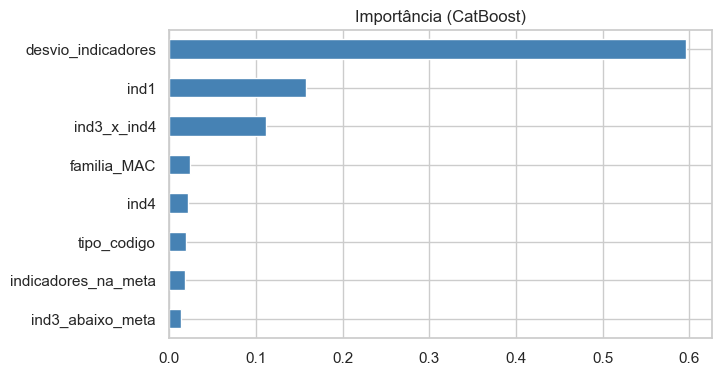

In [11]:
if escolhido == 'Stacking':
    # no stacking, o que dá para ler é o peso de cada modelo base na regressão logística
    importancias = pd.Series(abs(modelo_final.final_estimator_.coef_[0]), index=list(modelos))
else:
    importancias = pd.Series(modelo_final.feature_importances_, index=X.columns)

importancias = (importancias / importancias.sum()).sort_values(ascending=False).head(8)
importancias.sort_values().plot.barh(figsize=(7, 4), color='steelblue')
plt.title(f'Importância ({escolhido})')
plt.show()

## Salvando o resultado

In [12]:
nomes = {'ind1': 'indicador 1: medicamentos e MMH', 'ind2': 'indicador 2: gestão do trabalho',
         'ind3': 'indicador 3: satisfação do usuário', 'ind4': 'indicador 4: desempenho da unidade',
         'taxa_ind1': 'taxa de atendimento do indicador 1', 'ind3_x_ind4': 'indicador 3 x indicador 4',
         'ind3_abaixo_meta': 'indicador 3 abaixo da meta', 'indicadores_na_meta': 'indicadores na meta',
         'desvio_indicadores': 'desvio entre os indicadores', 'media_blocos_ind4': 'média dos blocos do indicador 4',
         'tipo_codigo': 'tipo de unidade', 'nivel_tipo': 'nível do tipo'}

def nome_legivel(coluna):
    return nomes.get(coluna, coluna.replace('familia_', 'tipo ').replace('distrito_', 'distrito '))

pd.DataFrame({'real': y_teste, 'previsto': previsto_final}).to_csv('../saidas/previsoes_classificacao.csv', index=False)

acuracia_referencia = max(y_teste.mean(), 1 - y_teste.mean())
final = resultados.loc[escolhido]

resultado = {
    'modelo': 'classificacao',
    'pergunta': 'A unidade fica abaixo de 90% no resultado geral?',
    'metodo': f'{escolhido}, escolhido entre XGBoost, LightGBM, CatBoost e o stacking dos três pelo F1 na validação cruzada em 5 partes. Hiperparâmetros por grid search, peso de classe e separação estratificada de 75% e 25%.',
    'metricas': {
        'acuracia': float(final['acurácia']),
        'precisao': float(final['precisão']),
        'revocacao': float(final['recall']),
        'f1': float(final['f1']),
        'amostras_teste': int(len(y_teste)),
        'positivos_no_teste': int(y_teste.sum()),
        'supera_referencia': bool(final['acurácia'] > acuracia_referencia),
        'importancias': [{'atributo': nome_legivel(c), 'peso': round(float(p), 3)} for c, p in importancias.items()],
    },
    'referencia': {'nome': 'chutar sempre a classe mais comum', 'acuracia': round(float(acuracia_referencia), 3)},
    'limitacao': 'O resultado geral é calculado a partir das mesmas notas, então o modelo aprende a regra da portaria. Serve para mostrar quais indicadores mais pesam, não para substituir o cálculo.',
}

with open('../saidas/classificacao.json', 'w', encoding='utf-8') as arquivo:
    json.dump(resultado, arquivo, ensure_ascii=False, indent=2)